In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

C:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# config
FILES = ["S07main_EpochedNoseRefCleanTimesFixed.mat"]
TOTAL_TIMES = 1229

In [3]:
# load .mat files
def get_field(struct, name):
    f = struct[name]
    if f.dtype == object:
        out = []
        for item in f.flatten():
            if isinstance(item, np.ndarray):
                out.append(item[0,0] if item.size==1 and item.ndim>1 else (item[0] if item.size==1 else item))
            else:
                out.append(item)
        return out
    return f.flatten() if f.size > 1 else f[0,0]

def load_files(files):
    vals, trials = [], []
    for f in files:
        dc = loadmat(f)["dataClean"][0,0]
        t  = np.array(get_field(dc, "trial"))
        ti = np.array(get_field(dc, "trialinfo")).reshape(len(t), 5)
        v  = ti[:, 1]
        vals.extend(v); trials.extend(t)
    trials = np.array(trials); vals = np.array(vals)
    mask   = (vals != -1) & (vals != 0)
    return vals[mask] - 1, trials[mask]

y, all_trials = load_files(FILES)
X_full = all_trials.transpose(0, 2, 1)
print(f"Trials: {len(y)}  |  Class 0: {(y==0).sum()}  Class 1: {(y==1).sum()}")

Trials: 222  |  Class 0: 134  Class 1: 88


In [ ]:
# split and normalise
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

mean = X_tr_raw.mean(axis=(0,1), keepdims=True)
std  = X_tr_raw.std(axis=(0,1),  keepdims=True) + 1e-6
X_train = (X_tr_raw  - mean) / std
X_test  = (X_te_raw  - mean) / std
print(f"Train/Test: {len(y_train)}/{len(y_test)}")

In [ ]:
# flatten raw EEG — no feature extraction
n, t, ch = X_train.shape
Xf_tr = X_train.reshape(n, -1)
Xf_te = X_test.reshape(len(y_test), -1)

scaler = StandardScaler()
Xf_tr = scaler.fit_transform(Xf_tr)
Xf_te = scaler.transform(Xf_te)
print(f"Flattened feature shape: {Xf_tr.shape}")

In [6]:
# SMOTE
sm = SMOTE(random_state=42)
Xf_tr_sm, y_tr_sm = sm.fit_resample(Xf_tr, y_train)
print(f"After SMOTE — Class 0: {(y_tr_sm==0).sum()}  Class 1: {(y_tr_sm==1).sum()}")

After SMOTE — Class 0: 82  Class 1: 82


In [7]:
# results helper
def show_results(name, y_true, y_pred):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["Class 0","Class 1"], digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Class 0","Class 1"], yticklabels=["Class 0","Class 1"])
    plt.title(name); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()


  SVM — Raw data (no feature extraction)
              precision    recall  f1-score   support

     Class 0     0.5581    0.9600    0.7059        25
     Class 1     0.5000    0.0500    0.0909        20

    accuracy                         0.5556        45
   macro avg     0.5291    0.5050    0.3984        45
weighted avg     0.5323    0.5556    0.4326        45



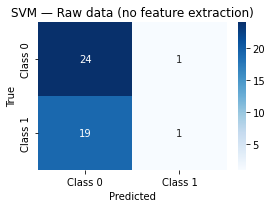


  SVM — Raw data + SMOTE (no feature extraction)
              precision    recall  f1-score   support

     Class 0     0.6053    0.9200    0.7302        25
     Class 1     0.7143    0.2500    0.3704        20

    accuracy                         0.6222        45
   macro avg     0.6598    0.5850    0.5503        45
weighted avg     0.6537    0.6222    0.5703        45



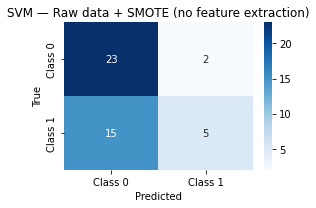

In [8]:
# SVM on normal raw data
svm_normal = SVC(kernel="rbf", C=1.0, random_state=42)
svm_normal.fit(Xf_tr, y_train)
show_results("SVM — Raw data (no feature extraction)", y_test, svm_normal.predict(Xf_te))

# SVM on SMOTE raw data
svm_smote = SVC(kernel="rbf", C=1.0, random_state=42)
svm_smote.fit(Xf_tr_sm, y_tr_sm)
show_results("SVM — Raw data + SMOTE (no feature extraction)", y_test, svm_smote.predict(Xf_te))